In [1]:
import pywt
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import os 
imgs=[]
for img in os.listdir("../dataset/whu_test_64_512/hr_512"):
    img_path = os.path.join("../dataset/whu_test_64_512/hr_512", img)
    if img.endswith('.png'):
        imgs.append(img_path)

In [12]:
# import cv2

# img=cv2.imread("/home/flyingbucket/CODE/datastore/Augsburg_data_4_publication/entire_city/HySpex.tif", cv2.IMREAD_GRAYSCALE)  
# print(type(img))         
# print(img.shape)         
# print(img is None)       
# plt.imshow(img, cmap='gray')


In [ ]:
# import tifffile as tiff

# img = tiff.memmap('/home/flyingbucket/CODE/datastore/Augsburg_data_4_publication/entire_city/Sentinel-2.tif',mode='r')
# print(img.shape)  

(888, 1371, 12)


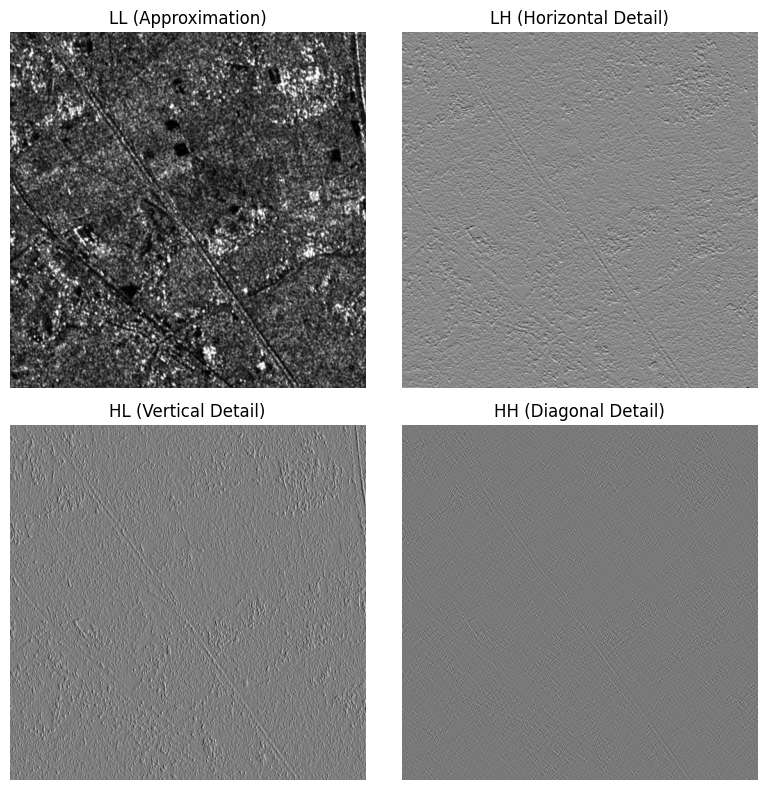

In [8]:
img = cv2.imread(imgs[0], cv2.IMREAD_GRAYSCALE)  
# 使用 'db1'（Haar）小波进行2D小波分解
coeffs2 = pywt.swt2(img, 'haar',level=1)
LL, (LH, HL, HH) = coeffs2[0]

# 显示四个子带
titles = ['LL (Approximation)', 'LH (Horizontal Detail)',
          'HL (Vertical Detail)', 'HH (Diagonal Detail)']
components = [LL, LH, HL, HH]

plt.figure(figsize=(8, 8))
for i, (comp, title) in enumerate(zip(components, titles)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(comp, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [9]:
print(components[0].shape)
print(img.shape)

(512, 512)
(512, 512)


In [4]:
import os
import shutil 
for file in os.listdir("../dataset"):
    if file.endswith(".png"):
        shutil.move(os.path.join("../dataset", file), os.path.join("../dataset", "whu_small_512", file))
  

In [6]:
wvl_dir="../dataset/whu_wavelet_img_64_512/sr_64_512"
import numpy as np
imgs=os.listdir(wvl_dir)
img_path=os.path.join(wvl_dir, imgs[0])
img=np.load(img_path)
print(img.shape)

(256, 256, 4)


In [ ]:
def check_shape(sr_path):
    imgs=os.listdir(sr_path)
    img_path=os.path.join(sr_path, imgs[0])
    img=np.load(img_path)
    print(img.shape)

In [13]:
check_shape("../dataset/whu_wavelet_img_64_512/sr_64_512")

(512, 512, 4)
